En este notebook se desarrolla la solución computacional de la ecuación de
Schrödinger con paquetes gaussianos como condiciones iniciales mediante el
método numérico Crank-Nicolson y la arquitectura de red neuronal Fourier
Neural Operator (FNO), finalmente se comparan sus tiempos de ejecución para
distintas cantidades de soluciones.

Inspiración y referencias: La implementación de Crank-Nicolson está
fuertemente inspirada en la exposición de Qijing Zheng
([Numerical Solutions to the Time-dependent Schrödinger Equation](http://staff.ustc.edu.cn/~zqj/posts/Numerical_TDSE/)),
que ofrece una explicación clara del método y su aplicación a sistemas cuánticos.
La arquitectura y metodología de FNO siguen el trabajo seminal de Li et al.
*Fourier Neural Operator for Partial Differential Equations* (ICLR 2021),
adaptando su enfoque al problema específico de la ecuación de Schrödinger.

# Ecuación de Schrödinger

La ecuación de Schrödinger es una de las ecuaciones fundamentales de la mecánica cuántica,
nos permite describir el estado cuántico de una partícula mediante una función de onda $\psi$,
la cual nos da información sobre la velocidad, posición, spin, energía y en general, observables
físicos. Su ecuación es:

$$\mathcal{H}\psi = E\psi$$

donde $\mathcal{H}$ es el operador Hamiltoniano y $E$ es la energía, definidos por:

$$\mathcal{H} = -\frac{\hbar^2}{2m}\nabla^2 + V, \qquad E = i\hbar\frac{\partial}{\partial t}$$

Igualando ambos lados se obtiene la ecuación de Schrödinger dependiente del tiempo:

$$i\hbar\frac{\partial \psi}{\partial t} = \left(-\frac{\hbar^2}{2m}\nabla^2 + V\right)\psi$$

Esta ecuación admite solución formal mediante el operador de evolución temporal

$$\psi(x, t) = e^{-i\mathcal{H}t/\hbar}\,\psi(x, 0)$$

El operador $U(t) = e^{-i\mathcal{H}t/\hbar}$ es un operador unitario, lo cual implica que la norma
de la función de onda se conserva en el tiempo:

$$\\|\psi(\cdot, 0)\| =  |\psi(\cdot, t)\| = 1$$

Esto tiene interpretación física directa al elevar la norma al cuadrado: la probabilidad total de encontrar la partícula
en algún punto del espacio permanece igual a $1$ para todo tiempo $t$.

## Planteamiento del problema



### Paquete de onda gaussiano

Como condición inicial se considera un paquete de onda gaussiano, que representa una
partícula localizada en torno a una posición $x_0$ con momento $k_0$:

$$\psi(x, 0) = \frac{1}{\sqrt{\sqrt{\pi}\,\sigma}} e^{-\frac{(x-x_0)^2}{2\sigma^2}} e^{ik_0(x-x_0)}$$

donde $\sigma$ controla el ancho del paquete. La función tiene dos componentes: la gaussiana
$e^{-(x-x_0)^2/2\sigma^2}$ localiza la partícula alrededor de $x_0$, y la onda plana
$e^{ik_0(x-x_0)}$ le confiere momento $k_0$, determinando su velocidad de propagación.


In [1]:
def gaussian_wavepacket(x, x0, k, sigma):
    g = np.sqrt(1 / (np.sqrt(np.pi) * sigma)) * np.exp(-(x - x0)**2 / (2 * sigma**2))
    return np.exp(1j * k * (x - x0)) * g

## Método de Crank-Nicolson

El operador de evolución temporal $U(t) = e^{-i\mathcal{H}t/\hbar}$ no puede computarse
directamente, por lo que se recurre a métodos numéricos para aproximarlo.

### Método de Euler hacia adelante

Partiendo de la ecuación de Schrödinger dependiente del tiempo:

$$i\hbar\frac{\partial \psi}{\partial t} = \mathcal{H}\psi$$

se despeja la derivada temporal:

$$\frac{\partial \psi}{\partial t} = -\frac{i}{\hbar}\mathcal{H}\psi$$

Aplicando el método de Euler hacia adelante $\psi^{n+1} = \psi^n + \Delta t \cdot f(\psi^n)$,
con $f(\psi) = -\frac{i}{\hbar}\mathcal{H}\psi$:

$$\psi_j^{n+1} = \psi_j^n - \frac{i\Delta t}{\hbar}\mathcal{H}\psi_j^n = \left(1 - \frac{i\mathcal{H}\Delta t}{\hbar}\right)\psi_j^n$$

Este método es explícito pero no preserva la unitariedad.

### Método de Euler hacia atrás

Aplicando ahora el método de Euler hacia atrás $\psi^{n+1} = \psi^n + \Delta t \cdot f(\psi^{n+1})$,
evaluando $f$ en el paso siguiente:

$$\psi_j^{n+1} = \psi_j^n - \frac{i\Delta t}{\hbar}\mathcal{H}\psi_j^{n+1}$$

Reordenando:

$$\left(1 + \frac{i\mathcal{H}\Delta t}{\hbar}\right)\psi_j^{n+1} = \psi_j^n$$

Este método es implícito e incondicionalmente estable, pero tampoco preserva la unitariedad.

### Método de Crank-Nicolson

El método de Crank-Nicolson fue originalmente propuesto para ecuaciones de difusión y
posteriormente adaptado a la ecuación de Schrödinger. En su forma moderna, promedia
los esquemas de Euler hacia adelante y hacia atrás evaluando $f$ a mitad del paso temporal:

$$\psi_j^{n+1} = \psi_j^n - \frac{i\Delta t}{\hbar}\mathcal{H}\left(\frac{\psi_j^{n+1} + \psi_j^n}{2}\right)$$

Reordenando:

$$\left(1 + \frac{i\mathcal{H}\Delta t}{2\hbar}\right)\psi_j^{n+1} = \left(1 - \frac{i\mathcal{H}\Delta t}{2\hbar}\right)\psi_j^n$$

Esta expresión corresponde a la **forma de Cayley** del operador unitario:

$$\mathcal{U}(\Delta t) \approx \frac{1 - i\mathcal{H}\Delta t/2}{1 + i\mathcal{H}\Delta t/2}$$

que es una aproximación de Padé $(1,1)$ de $e^{-i\mathcal{H}\Delta t}$, unitaria por construcción
y de orden 2 en $\Delta t$.

### Discretización espacial y sistema lineal

Discretizando el operador cinético $-\frac{\hbar^2}{2m}\nabla^2$ mediante diferencias
finitas centradas de segundo orden sobre una grilla uniforme con paso $\Delta x$, el
Hamiltoniano se aproxima como la matriz tridiagonal:

$$T_{j,j} = \frac{1}{\Delta x^2}, \qquad T_{j,j\pm 1} = -\frac{1}{2\Delta x^2}$$

El operador potencial $\hat{V}$ es diagonal:

$$V = \text{Diag}[v_0 \quad v_1 \quad v_2 \quad \cdots \quad v_J]$$

Con esto, el esquema de Crank-Nicolson toma la forma matricial:

$$U_2 \cdot \Psi^{n+1} = U_1 \cdot \Psi^n$$

$$U_2 = \mathbb{I} + \frac{i\Delta t}{2}\cdot[T + V], \qquad U_1 = \mathbb{I} - \frac{i\Delta t}{2}\cdot[T + V]$$

En cada paso temporal se resuelve el sistema lineal $U_2 \cdot \Psi^{n+1} = U_1 \cdot \Psi^n$.
Dado que $U_2$ es tridiagonal y no cambia entre pasos temporales, se factoriza una única
vez mediante descomposición LU antes del loop temporal, reduciendo el costo de cada paso
a dos sustituciones triangulares de complejidad $\mathcal{O}(N)$.

In [2]:
def build_CN_matrices(V, x, dt):
    J  = x.size - 1
    dx = x[1] - x[0]
    O  = np.ones(J + 1)
    T  = (-1 / 2 / dx**2) * spa.spdiags([O, -2*O, O], [-1, 0, 1], J+1, J+1)
    H  = T + spa.diags(V)
    U2 = (spa.eye(J+1) + (1j * 0.5 * dt) * H).tocsc()
    U1 =  spa.eye(J+1) - (1j * 0.5 * dt) * H
    return splu(U2), U1


def solve_CN(psi0, LU, U1, N_steps, t_out_idx):
    psi       = psi0.copy()
    out_set   = set(t_out_idx)
    snapshots = np.zeros((len(psi0), len(t_out_idx)), dtype=complex)
    out_count = 0
    for n in range(N_steps):
        if n in out_set:
            snapshots[:, out_count] = psi
            out_count += 1
        psi = LU.solve(U1.dot(psi))
    return snapshots

In [3]:
def compute_norm(psi, x):
    return np.trapezoid(np.abs(psi)**2, x)


def psi_to_channels(psi, V=None):
    if V is not None and V.max() > 0:   # solo añade V si tiene valores no nulos
        return np.stack([psi.real, psi.imag, V / V.max()], axis=-1)
    return np.stack([psi.real, psi.imag], axis=-1)


def sample_params(n):
    x0_vals    = np.linspace(-2, 2, 22)
    k0_vals    = np.linspace(0, 3, 22)
    sigma_vals = np.linspace(0.3, 0.6, 22)
    combos = [(x0, k0, s)
              for x0 in x0_vals
              for k0 in k0_vals
              for s  in sigma_vals]   # 22³ = 10648 combinaciones
    arr = np.array(combos[:n])
    return arr[:, 0], arr[:, 1], arr[:, 2]


def generate_split(n_samples, LU, U1, label="", V=None):
    n_channels = 3 if V is not None and V.max() > 0 else 2
    inputs  = np.zeros((n_samples, J+1, n_channels), dtype=np.float32)
    outputs = np.zeros((n_samples, J+1, N_t_out, 2), dtype=np.float32)
    params  = np.zeros((n_samples, 3),               dtype=np.float32)
    norms   = np.zeros((n_samples, N_t_out),         dtype=np.float32)

    x0_arr, k0_arr, sigma_arr = sample_params(n_samples)

    for i in range(n_samples):
        if (i + 1) % 100 == 0 or i == 0:
            print(f"  [{label}] {i+1}/{n_samples}")
        psi0  = gaussian_wavepacket(x, x0_arr[i], k0_arr[i], sigma_arr[i])
        psi0 /= np.sqrt(compute_norm(psi0, x))
        traj  = solve_CN(psi0, LU, U1, N_steps, t_out_idx)
        inputs[i] = psi_to_channels(psi0, V)
        outputs[i] = psi_to_channels(traj)
        params[i]  = [x0_arr[i], k0_arr[i], sigma_arr[i]]
        norms[i]   = [compute_norm(traj[:, t], x) for t in range(N_t_out)]

    return inputs, outputs, params, norms

In [4]:
import numpy as np
import scipy.sparse as spa
from scipy.sparse.linalg import splu
from pathlib import Path


L    = 20.0
J    = 999
x    = np.linspace(-L/2, L/2, J+1, endpoint=True)
dx   = x[1] - x[0]

# Sin potencial
V = np.zeros(J+1)

sigmax_base = 0.4
k0_base     = 0
dt      = 2 / (2 * np.pi / sigmax_base + k0_base)**2
N_steps = int(2 / dt) + 1
T_final = N_steps * dt
N_t_out = N_steps

t_out_idx = np.linspace(0, N_steps - 1, N_t_out, dtype=int)
t_out     = t_out_idx * dt

# Dataset
N_train = 800
N_val   = 100
N_test  = 100

In [5]:
def generate_dataset(V=None):
    print(f"dt={dt:.4f}, N_steps={N_steps}, T_final={T_final:.2f}")
    print(f"Muestras: {N_train} train / {N_val} val / {N_test} test\n")
    if V is None:
        V = np.zeros(J+1)
    LU, U1 = build_CN_matrices(V, x, dt)

    X_tr, Y_tr, P_tr, norms_tr    = generate_split(N_train, LU, U1, "train", V=V)
    X_val, Y_val, P_val, norms_val = generate_split(N_val,   LU, U1, "val",   V=V)
    X_te, Y_te, P_te, norms_te    = generate_split(N_test,  LU, U1, "test",  V=V)

    out_dir = Path("data")
    out_dir.mkdir(exist_ok=True)
    for name, X, Y, P, nrm in [("train", X_tr, Y_tr, P_tr, norms_tr),
                                 ("val",   X_val, Y_val, P_val, norms_val),
                                 ("test",  X_te,  Y_te,  P_te,  norms_te)]:
        np.savez(out_dir / f"{name}.npz",
                 inputs=X, outputs=Y, params=P, norms=nrm,
                 x=x, t_out=t_out, V=V)

    print(f"\ntrain: inputs {X_tr.shape}, outputs {Y_tr.shape}")
    print(f"Norma media: {norms_tr.mean():.6f}, desvío máx: {np.abs(norms_tr-1).max():.2e}")

In [6]:
generate_dataset()

dt=0.0081, N_steps=247, T_final=2.00
Muestras: 800 train / 100 val / 100 test

  [train] 1/800
  [train] 100/800
  [train] 200/800
  [train] 300/800
  [train] 400/800
  [train] 500/800
  [train] 600/800
  [train] 700/800
  [train] 800/800
  [val] 1/100
  [val] 100/100
  [test] 1/100
  [test] 100/100

train: inputs (800, 1000, 2), outputs (800, 1000, 247, 2)
Norma media: 1.000000, desvío máx: 2.24e-05


## Importar librerías

In [7]:
import numpy as np
from pathlib import Path
from functools import partial
import time

import jax
import jax.numpy as jnp
import flax.linen as nn
from flax.linen.initializers import uniform
from flax.training import train_state
import optax
from einops import rearrange

## Fourier Integral Operator

Sea $\mathcal{F}$ la transformada de Fourier de una función $f: D \to \mathbb{R}^{d_v}$ y $\mathcal{F}^{-1}$ su inversa. Partiendo del operador integral de kernel

$$\left(\mathcal{K}(a;\phi)v_t\right)(x) := \int_D \kappa\left(x, y, a(x), a(y); \phi\right) v_t(y) \, dy, \qquad \forall x \in D$$

Eligiendo $\kappa_\phi(x, y, a(x), a(y)) = \kappa_\phi(x-y)$, el operador integral se convierte en una convolución:

$$\left(\mathcal{K}(a;\phi)v_t\right)(x) = \int_D \kappa_\phi(x-y)\, v_t(y)\, dy$$

Aplicando $\mathcal{F}$ a ambos lados y usando el teorema de convolución $\mathcal{F}(f * g) = \mathcal{F}(f) \cdot \mathcal{F}(g)$:

$$\mathcal{F}\left(\left(\mathcal{K}(a;\phi)v_t\right)(x)\right) = \mathcal{F}\left((\kappa_\phi * v_t)(x)\right) = \left(\mathcal{F}(\kappa_\phi) \cdot \mathcal{F}(v_t)\right)(x)$$

Aplicando $\mathcal{F}^{-1}$ a ambos lados:

$$\left(\mathcal{K}(a;\phi)v_t\right)(x) = \mathcal{F}^{-1}\!\left(\mathcal{F}(\kappa_\phi) \cdot \mathcal{F}(v_t)\right)(x)$$

Dado que los parámetros de $\kappa_\phi$ se aprenden directamente en el espacio de Fourier, se parametriza $R_\phi = \mathcal{F}(\kappa_\phi)$ como tensor de pesos aprendibles, definiendo el Fourier Integral Operator:

$$\left(\mathcal{K}(\phi)v_t\right)(x) = \mathcal{F}^{-1}\!\left(R_\phi \cdot \left(\mathcal{F}v_t\right)\right)(x), \qquad \forall x \in D$$




### Discretización del Fourier Integral Operator
Dado que $\kappa_\phi$ es periódico, admite una expansión en serie de Fourier y se trabaja con modos discretos $k \in \mathbb{Z}^d$. Para obtener una parametrización de dimensión finita, se trunca la serie a un número máximo de modos $k_{\max}$, parametrizando directamente $R_\phi \in \mathbb{C}^{k_{\max} \times d_v \times d_v}$ como tensor de pesos aprendibles en el espacio de Fourier:

$$\left(\mathcal{K}(\phi)v_t\right)(x) = \mathcal{F}^{-1}\!\left(R_\phi \cdot \left(\mathcal{F}v_t\right)\right)(x), \qquad \forall x \in D$$

donde la multiplicación modal está dada por

$$\left(R \cdot (\mathcal{F}v_t)\right)_{k,l} = \sum_{j=1}^{d_v} R_{k,l,j}\,(\mathcal{F}v_t)_{k,j}, \qquad k = 1, \ldots, k_{\max}, \quad l = 1, \ldots, d_v$$



In [8]:
class SpectralConv1d(nn.Module):
    in_channels: int
    d_vars: int
    n_modes: int
    linear_conv: bool = True

    def setup(self):
        weight_shape = (self.in_channels, self.d_vars, self.n_modes)
        scale = 1 / (self.in_channels * self.d_vars)
        self.weight_real = self.param("weight_real", uniform(scale=scale), weight_shape) # Re(R)
        self.weight_imag = self.param("weight_imag", uniform(scale=scale), weight_shape) # Im(R)

    def __call__(self, x):           # x: (W, C), x es v_t
        W, C = x.shape
        X    = jnp.fft.rfft(x, n=W * 2 - 1, axis=-2, norm="ortho") # F(v_t), ortho es para preservar la norma de la función (señal)
        X    = X[: self.n_modes, :] # truncación de k_max
        cw   = self.weight_real + 1j * self.weight_imag
        X    = jnp.einsum("ki,iok->ko", X, cw) # (RF(v_t))
        return jnp.fft.irfft(X, n=W * 2 - 1, axis=-2, norm="ortho")[:W] # F^{-1}(RF(v_t))

El parámetro $n$ es el número de puntos con los que rfft trata a la señal, básicamente le dice a rfft que trate la señal como si tuviera $n$ puntos, y se tienen los siguientes casos:

Si $n > W$, como es este caso con $n=2W-1 > W$, entonces añade ceros a la señal hasta alcanzar $n$, esto se conoce como zero-padding.

Si $n < W$, trunca los primeros $n$ puntos de la señal.

Si se deja vacío, por default se respetan los puntos que tiene la señal.

Por defecto, fft asume que nuestra función es periódica de periodo $N$, entonces aplica una convolución circular. Aquí se usa $n=2W-1$ para hacer que la convolución sea lineal. ¿Por qué?

### Convolución Lineal
Sean $f$ y $g$ dos señales de longitud $N$ definidas sobre $\mathbb{Z}$, su convolución lineal es
$$(f * g)[n] = \sum_{k=0}^{N-1} f[k] \cdot g[n - k]$$
donde $g[n-k] = 0$ si $n - k < 0$ o $n - k \geq N$. El resultado tiene longitud $2N - 1$, ya que el primer índice no nulo ocurre en $n = 0$ y el último cuando los últimos elementos de $f$ y $g$ se alinean, es decir $n = (N-1) + (N-1) = 2N-2$, dando un total de $2N-1$ elementos. Los extremos no se envuelven ya que $f$ y $g$ viven en $\mathbb{Z}$, cuando $k$ sale del rango simplemente no hay solapamiento y el resultado es $0$.

### Convolución Circular
Sean $f$ y $g$ dos señales de longitud $N$ definidas sobre $\mathbb{Z}/N\mathbb{Z}$, su convolución circular es
$$(f \circledast g)[n] = \sum_{k=0}^{N-1} f[k] \cdot g[(n - k) \bmod N]$$
Aquí $f$ y $g$ viven en el grupo cociente $\mathbb{Z}/N\mathbb{Z}$, que topológicamente es un círculo. El $\bmod N$ es exactamente la estructura de grupo de $\mathbb{Z}/N\mathbb{Z}$: identificas $N \sim 0$, $N+1 \sim 1$, y así sucesivamente. Cuando $g$ se desliza más allá del extremo derecho, reaparece por el extremo izquierdo. Esto introduce artefactos en señales no periódicas como $\psi(x)$, donde el extremo derecho del dominio interactuaría artificialmente con el extremo izquierdo.

### Zero-padding como solución
La convolución circular de dos señales de longitud $L$ es equivalente a la convolución lineal si $L \geq 2N - 1$. Usando exactamente $L = 2W - 1$, se extiende la señal añadiendo $W-1$ ceros al final:

$$f_{\text{pad}} = [f_0, f_1, \ldots, f_{W-1}, \underbrace{0, \ldots, 0}_{W-1}]$$

Ahora la señal paddeada vive en $\mathbb{Z}/(2W-1)\mathbb{Z}$, pero los ceros eliminan ese comportamiento circular: cuando $g$ se enrolla y accede a posiciones más allá de $W-1$, encuentra ceros en lugar de valores reales de $f$, reproduciendo exactamente el comportamiento de la convolución lineal en $\mathbb{Z}$. Finalmente, `[:W]` recorta el resultado a los primeros $W$ puntos para recuperar el tamaño original de la señal.

In [9]:
class SpectralLayers1d(nn.Module):
    n_channels: int
    n_modes: int
    linear_conv: bool = True
    n_layers: int = 4
    activation: nn.Module = nn.gelu

    def setup(self):
        self.layers_conv = [
            SpectralConv1d(self.n_channels, self.n_channels, self.n_modes, self.linear_conv)
            for _ in range(self.n_layers)
        ]
        self.layers_w = [
            nn.Conv(features=self.n_channels, kernel_size=(1,))
            for _ in range(self.n_layers)
        ]

    def __call__(self, x):
        for conv, w in zip(self.layers_conv, self.layers_w):
            x = self.activation(conv(x) + w(x))
        return x

La arquitectura completa define una sucesión $(v_j)_{j=0}^{T}$ donde cada $v_j : D \to \mathbb{R}^{d_v}$, mediante las actualizaciones iterativas

$$v_{t+1}(x) := \sigma\!\left(W v_t(x) + \left(\mathcal{K}(\phi)v_t\right)(x)\right), \qquad \forall x \in D$$

con $W : \mathbb{R}^{d_v} \to \mathbb{R}^{d_v}$ una transformación lineal local y $\sigma$ una función de activación no lineal aplicada componente a componente. La entrada $a \in \mathcal{A}$ es elevada al espacio de alta dimensión mediante $v_0(x) = P(a(x))$, y la salida se obtiene proyectando $v_T$ mediante $u(x) = Q(v_T(x))$, donde $P$ y $Q$ son transformaciones locales parametrizadas por redes densas.

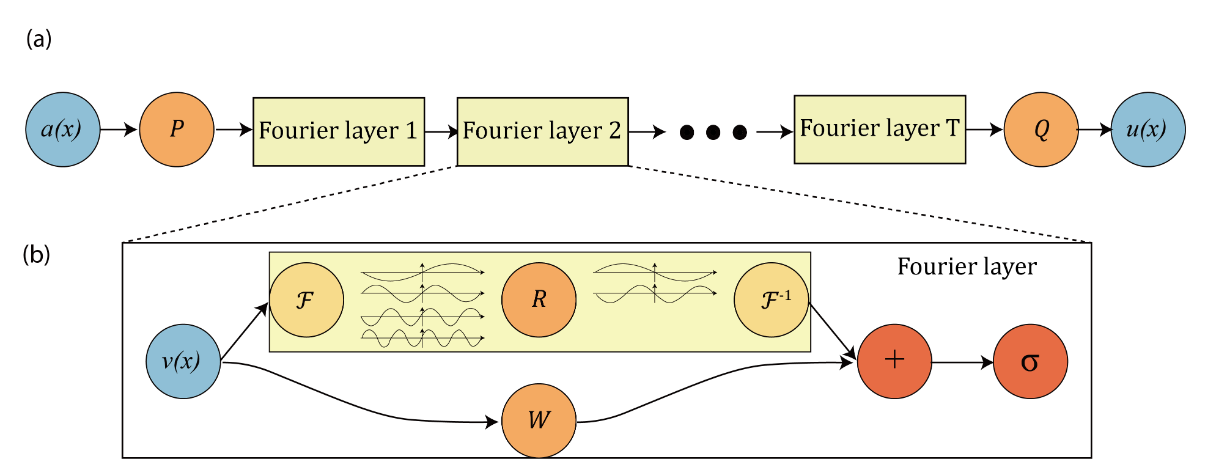

In [10]:
class FNO1D(nn.Module):
    hidden_channels: int
    n_modes:         int
    d_vars:          int  = 2      # Re y Im → 2 canales de salida
    n_steps:         int  = 20     # snapshots de salida
    n_layers:        int  = 4
    use_potential:   bool = False  # True si se incluye V como canal de entrada
    activation: nn.Module = nn.gelu

    @nn.compact
    def __call__(self, x):     # x: (1, W, 2) o (1, W, 3) si use_potential=True
        # Aplanar dimensión temporal como canal
        x = rearrange(x, "t w c -> w (t c)")

        # Elevar al espacio de alta dimensión, basicamente es P, donde v_0 = P(a_0)
        # Dense acepta 2 canales [Re, Im] o 3 canales [Re, Im, V] automáticamente
        h = nn.Dense(features=self.hidden_channels)(x)

        # Capas espectrales
        h = SpectralLayers1d(
            n_channels=self.hidden_channels,
            n_modes=self.n_modes,
            n_layers=self.n_layers,
            activation=self.activation,
        )(h)

        # Proyectar a la salida, proyección Q
        y = nn.Sequential([
            nn.Dense(features=128),
            self.activation,
            nn.Dense(features=self.d_vars * self.n_steps),
        ])(h)

        return rearrange(y, "w (t c) -> t w c", t=self.n_steps, c=self.d_vars)


In [11]:
# vmap sobre el batch
BatchedFNO1D = nn.vmap(
    FNO1D,
    in_axes=0, out_axes=0,
    variable_axes={"params": None},
    split_rngs={"params": False},
)

## Carga de datos

In [12]:
def load_data(path):
    d = np.load(path)
    # inputs : (N, W, 2) → añadir dim temporal: (N, 1, W, 2)
    X = d["inputs"][:, np.newaxis, :, :]       # (N, 1, W, 2)
    # outputs: (N, W, T, 2) → transponer a (N, T, W, 2)
    Y = d["outputs"].transpose(0, 2, 1, 3)      # (N, T, W, 2)
    return jnp.array(X, dtype=jnp.float32), jnp.array(Y, dtype=jnp.float32)


def make_batches(X, Y, batch_size, rng=None, shuffle=True):
    N = X.shape[0]
    if shuffle and rng is not None:
        idx = jax.random.permutation(rng, N)
        X, Y = X[idx], Y[idx]
    for i in range(0, N, batch_size):
        yield X[i:i+batch_size], Y[i:i+batch_size]

## Métricas físicas

In [13]:
def to_complex(arr):
    """(... W, 2) → (... W) complejo"""
    return arr[..., 0] + 1j * arr[..., 1]


def norm_error(pred, x_grid):
    """
    Desvío de conservación de norma: |<||ψ||²> - 1|
    pred: (T, W, 2)
    """
    psi = to_complex(pred) # (T, W)
    dx  = x_grid[1] - x_grid[0]
    norms = jnp.sum(jnp.abs(psi)**2, axis=-1) * dx   # (T,)
    return jnp.abs(norms - 1.0).mean()


def relative_l2(pred, true):
    """Error L2 relativo sobre todos los tiempos."""
    num = jnp.sum((pred - true)**2)
    den = jnp.sum(true**2) + 1e-8
    return jnp.sqrt(num / den)

## Funciones de entrenamiento

In [14]:
@partial(jax.jit, static_argnums=(0,))
def train_step(model, state, X_batch, Y_batch):
    def loss_fn(params):
        Y_pred = model.apply({"params": params}, X_batch)
        # MSE sobre los dos canales y todos los tiempos
        return jnp.mean((Y_pred - Y_batch)**2)

    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    return state, loss


@partial(jax.jit, static_argnums=(0,))
def eval_step(model, state, X_batch, Y_batch):
    Y_pred = model.apply({"params": state.params}, X_batch)
    mse    = jnp.mean((Y_pred - Y_batch)**2)
    rel_l2 = relative_l2(Y_pred, Y_batch)
    return Y_pred, mse, rel_l2

In [15]:
CONFIG = dict(
    hidden_channels = 32,
    n_modes         = 64, # modos de Fourier a retener (frequencias "básicas" de la función)
    n_layers        = 4,
    n_steps         = N_steps,  # debe coincidir con el dataset
    batch_size      = 16,
    n_epochs        = 50,
    learning_rate   = 1e-3,
    seed            = 0,
)

## Main Function
Aquí se hace todo, se cargan los datos, se inicializa el modelo de acuerdo a CONFIG, se elige el optimizador, en este caso adam, se entrena el modelo y se hace su respectiva evaluación, se mide el error y la conservación de la norma, la cual es clave ya que el operador solución $e^{-i\mathcal{H}t}$ es un operador unitario.

In [16]:
import time as time_module
def main(model):
    print("=" * 60)
    print("Entrenamiento FNO1D — Ec. de Schrödinger")
    print("=" * 60)

    # ── Cargar datos ──────────────────────────────────────────
    data_dir = Path("data")
    print("Cargando datos...")
    X_tr, Y_tr   = load_data(data_dir / "train.npz")
    X_val, Y_val = load_data(data_dir / "val.npz")
    X_te, Y_te   = load_data(data_dir / "test.npz")

    # Grid espacial (para métricas de norma)
    x_grid = jnp.array(np.load(data_dir / "train.npz")["x"], dtype=jnp.float32)

    print(f"  Train : {X_tr.shape}  →  {Y_tr.shape}")
    print(f"  Val   : {X_val.shape} →  {Y_val.shape}")
    print(f"  Test  : {X_te.shape}  →  {Y_te.shape}\n")

    rng      = jax.random.PRNGKey(CONFIG["seed"])
    rng, r1  = jax.random.split(rng)
    dummy_in = X_tr[:1]                           # (1, 1, W, 2)
    params   = model.init(r1, dummy_in)["params"]

    n_params = sum(p.size for p in jax.tree_util.tree_leaves(params))
    print(f"Parámetros del modelo: {n_params:,}\n")

    # ── Optimizador ──────────────────────────────────────────
    schedule = optax.cosine_decay_schedule(
        init_value  = CONFIG["learning_rate"],
        decay_steps = CONFIG["n_epochs"] * (X_tr.shape[0] // CONFIG["batch_size"]),
    )
    optimizer = optax.adam(schedule)
    state     = train_state.TrainState.create(
        apply_fn = model.apply,
        params   = params,
        tx       = optimizer,
    )

    # ── Loop de entrenamiento ────────────────────────────────
    best_val_loss = float("inf")
    history = {"train_loss": [], "val_loss": [], "val_rel_l2": []}

    print(f"{'Época':>6} | {'Train MSE':>10} | {'Val MSE':>10} | {'Val L2 rel':>10} | {'Tiempo':>7}")
    print("-" * 55)

    for epoch in range(1, CONFIG["n_epochs"] + 1):
        t0 = time_module.time()
        rng, r2 = jax.random.split(rng)

        # ── Train ──
        train_losses = []
        for Xb, Yb in make_batches(X_tr, Y_tr, CONFIG["batch_size"], r2):
            state, loss = train_step(model, state, Xb, Yb)
            train_losses.append(float(loss))
        train_loss = np.mean(train_losses)

        # ── Val ──
        val_losses, val_l2s = [], []
        for Xb, Yb in make_batches(X_val, Y_val, CONFIG["batch_size"], shuffle=False):
            _, mse, rel_l2 = eval_step(model, state, Xb, Yb)
            val_losses.append(float(mse))
            val_l2s.append(float(rel_l2))
        val_loss = np.mean(val_losses)
        val_l2   = np.mean(val_l2s)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_rel_l2"].append(val_l2)

        elapsed = time_module.time() - t0
        print(f"{epoch:>6} | {train_loss:>10.2e} | {val_loss:>10.2e} | {val_l2:>10.4f} | {elapsed:>6.1f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_params   = state.params

    # ── Evaluación final en test ─────────────────────────────
    print("\n" + "=" * 60)
    print("Evaluación en test set")
    state_best = state.replace(params=best_params)

    test_mse, test_l2, test_norm_err = [], [], []
    for Xb, Yb in make_batches(X_te, Y_te, CONFIG["batch_size"], shuffle=False):
        Y_pred, mse, rel_l2 = eval_step(model, state_best, Xb, Yb)
        test_mse.append(float(mse))
        test_l2.append(float(rel_l2))
        # Norma para cada muestra del batch, último tiempo
        for i in range(Y_pred.shape[0]):
            test_norm_err.append(float(norm_error(Y_pred[i], x_grid)))

    print(f"  MSE          : {np.mean(test_mse):.4e}")
    print(f"  L2 relativo  : {np.mean(test_l2):.4f}")
    print(f"  Error norma  : {np.mean(test_norm_err):.4e}  (0 = conservación perfecta)")

    # ── Guardar historia ─────────────────────────────────────
    np.savez("fno_history.npz", **{k: np.array(v) for k, v in history.items()})
    print("\nHistorial guardado en fno_history.npz")
    print("=" * 60)
    return best_params, model

In [17]:
model = BatchedFNO1D(
    hidden_channels = CONFIG["hidden_channels"],
    n_modes         = CONFIG["n_modes"],
    n_steps         = CONFIG["n_steps"],
    n_layers        = CONFIG["n_layers"],
    use_potential   = False,
)

In [18]:
if __name__ == "__main__":
    best_params, model = main(model)

Entrenamiento FNO1D — Ec. de Schrödinger
Cargando datos...
  Train : (800, 1, 1000, 2)  →  (800, 247, 1000, 2)
  Val   : (100, 1, 1000, 2) →  (100, 247, 1000, 2)
  Test  : (100, 1, 1000, 2)  →  (100, 247, 1000, 2)

Parámetros del modelo: 596,558

 Época |  Train MSE |    Val MSE | Val L2 rel |  Tiempo
-------------------------------------------------------
     1 |   1.28e-02 |   2.48e-03 |     0.3144 |    7.9s
     2 |   2.29e-03 |   5.00e-04 |     0.1402 |    0.5s
     3 |   7.88e-04 |   2.11e-04 |     0.0907 |    0.5s
     4 |   4.49e-04 |   1.33e-04 |     0.0719 |    0.5s
     5 |   3.02e-04 |   9.76e-05 |     0.0615 |    0.5s
     6 |   2.28e-04 |   7.91e-05 |     0.0553 |    0.5s
     7 |   1.81e-04 |   6.39e-05 |     0.0496 |    0.5s
     8 |   1.48e-04 |   5.76e-05 |     0.0471 |    0.5s
     9 |   1.25e-04 |   4.79e-05 |     0.0429 |    0.5s
    10 |   1.07e-04 |   4.23e-05 |     0.0402 |    0.5s
    11 |   9.32e-05 |   3.81e-05 |     0.0381 |    0.5s
    12 |   8.26e-05 |   3

El operador aproximado $G^\dagger: \mathcal{A} \to \mathcal{U}$ es la red neuronal completa, esa red aprende el mapeo desde el espacio de funciones de condiciones iniciales $\psi_0$ al espacio de soluciones $u_j$, es decir, dado un estado inicial, el operador predice la función de onda en todos los tiempos de salida, matemáticamente $\psi_0 \to \{\psi(\cdot, t_1), \psi(\cdot, t_2), \dots, \psi(\cdot, t_T) \}$.

# Crank-Nicolson vs FNOs

In [19]:
def solve_CN_full(psi0, LU, U1, N_steps):
    psi   = psi0.copy()
    PSI   = np.zeros((len(psi0), N_steps), dtype=complex)
    PSI[:, 0] = psi
    for n in range(1, N_steps):
        psi = LU.solve(U1.dot(psi))
        PSI[:, n] = psi
    return PSI

In [20]:
LU, U1 = build_CN_matrices(V, x, dt)
psi0 = gaussian_wavepacket(x, x0=0, k=0, sigma=0.4)
psi0 /= np.sqrt(compute_norm(psi0, x))

PSI_cn = solve_CN_full(psi0, LU, U1, N_steps)

In [21]:
x_in   = jnp.array(np.stack([psi0.real, psi0.imag], axis=-1)[None, None], dtype=jnp.float32)
y_pred = np.array(model.apply({"params": best_params}, x_in)[0])  # (T, W, 2)
PSI_fno = (y_pred[..., 0] + 1j * y_pred[..., 1])  # (W, T)

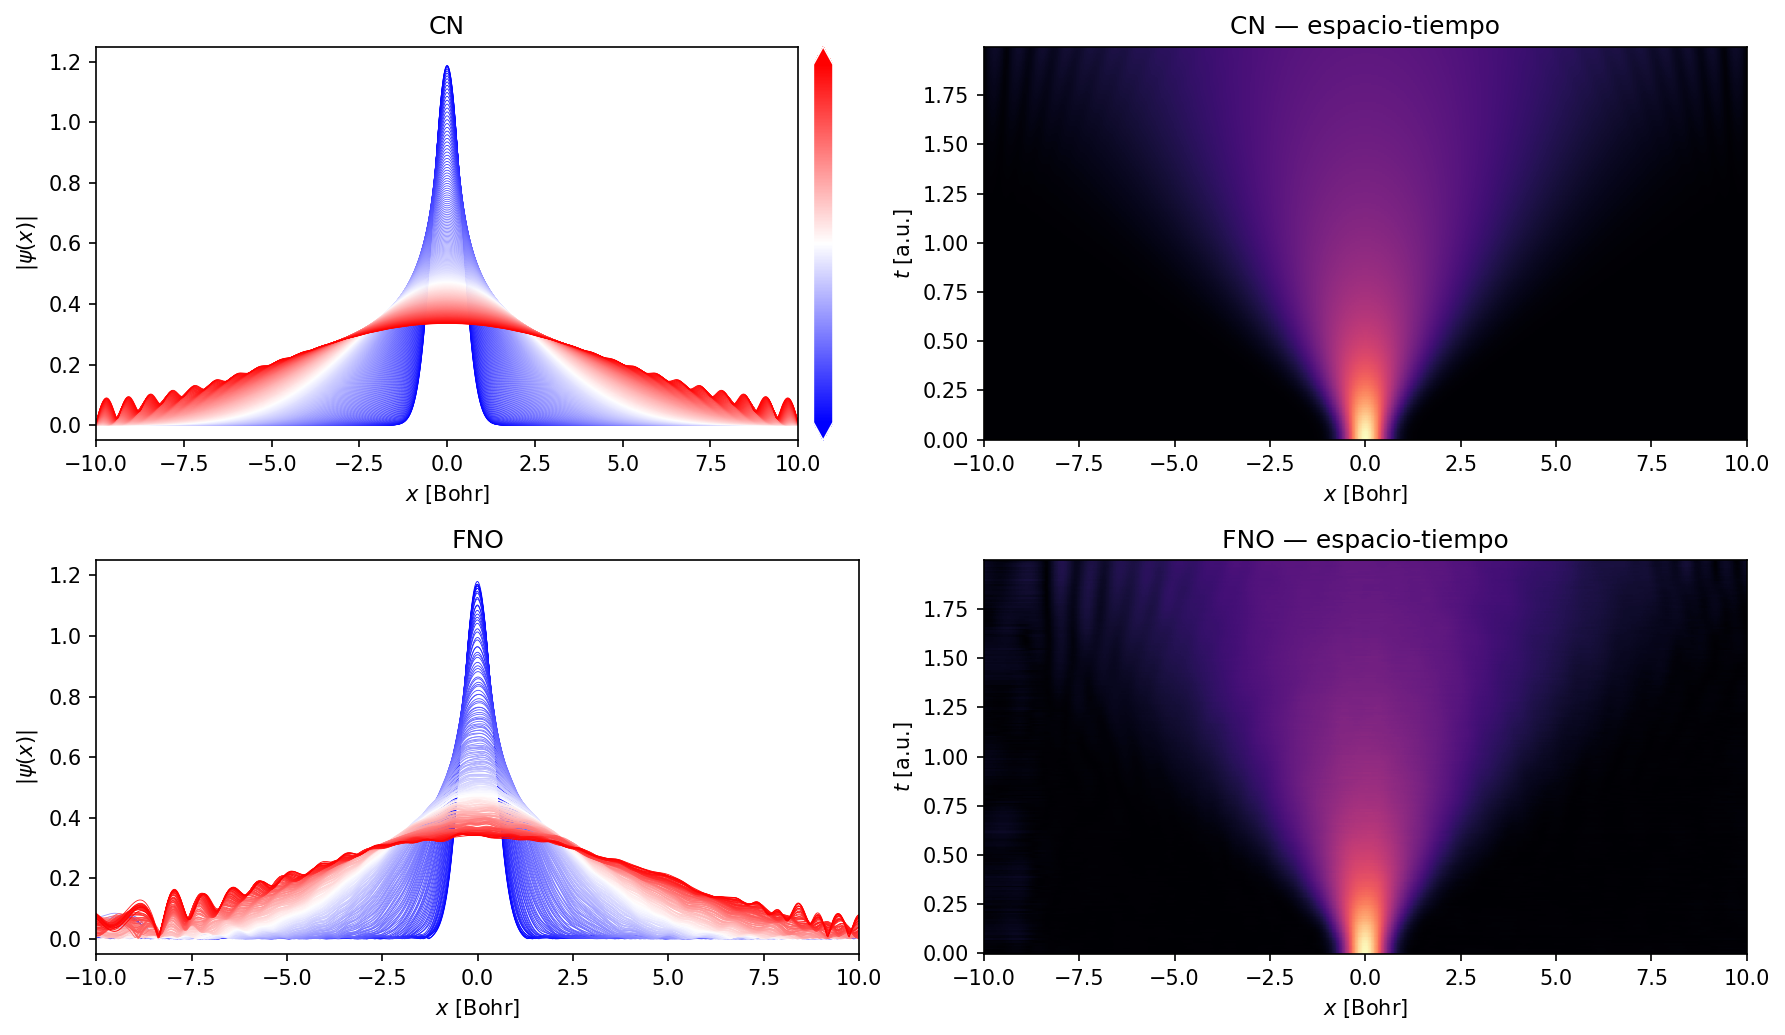

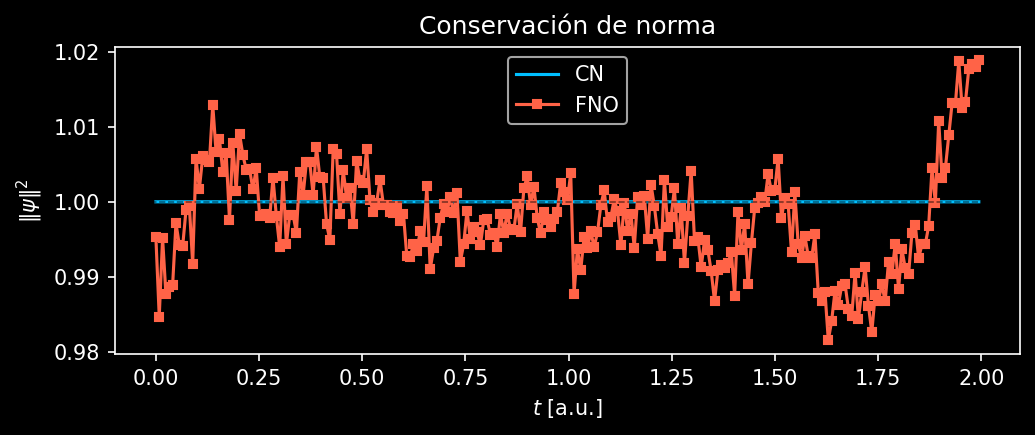

In [22]:
import matplotlib as mpl
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(12, 7), dpi=150)
plt.style.use('dark_background')

for row, (label, PSI) in enumerate([("CN", PSI_cn), ("FNO", PSI_fno)]):
    ax = axes[row, 0]

    if label == "CN":
        for ii in range(N_steps):
            ax.plot(x, np.abs(PSI[:, ii]), color=mpl.cm.bwr(ii / N_steps), lw=0.4)
        fig.colorbar(
            mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=N_steps*dt), cmap='bwr'),
            ax=ax, fraction=0.06, pad=0.02, extend='both', shrink=1.0, ticks=range(3)
        ).ax.set_title(r'$t$ [a.u.]', fontsize='x-small')
    else:
        for ii in range(PSI_fno.shape[0]):
            ax.plot(x, np.abs(PSI[ii, :]), color=mpl.cm.bwr(ii / PSI_fno.shape[0]), lw=0.4)

    ax.set_xlim(-L/2, L/2); ax.set_ylim(-0.05, 1.25)
    ax.set_xlabel(r'$x$ [Bohr]'); ax.set_ylabel(r'$|\psi(x)|$')
    ax.set_title(label)

    ax = axes[row, 1]
    if label == "CN":
        t_ax = np.arange(N_steps) * dt
        PSI_plot = np.abs(PSI_cn).T
    else:
        t_ax = t_out[:PSI_fno.shape[0]]
        PSI_plot = np.abs(PSI_fno)
    ax.pcolormesh(x, t_ax, PSI_plot, cmap='magma', shading='auto')
    ax.set_xlabel(r'$x$ [Bohr]'); ax.set_ylabel(r'$t$ [a.u.]')
    ax.set_title(f"{label} — espacio-tiempo"); ax.set_xlim(-L/2, L/2)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3), dpi=150)
plt.style.use('dark_background')
norms_cn  = [np.trapezoid(np.abs(PSI_cn[:,  i])**2, x) for i in range(N_steps)]
norms_fno = [np.trapezoid(np.abs(PSI_fno[i, :])**2, x) for i in range(PSI_fno.shape[0])]
t_cn_norm  = np.arange(N_steps) * dt
t_fno_norm = t_out[:PSI_fno.shape[0]]
plt.plot(t_cn_norm,  norms_cn,  '-',  label='CN',  color='deepskyblue', lw=1.5)
plt.plot(t_fno_norm, norms_fno, 's-', label='FNO', color='tomato',      lw=1.5, ms=4)
plt.axhline(1.0, color='black', lw=0.8, ls='--', alpha=0.5)
plt.xlabel(r'$t$ [a.u.]'); plt.ylabel(r'$\|\psi\|^2$')
plt.title('Conservación de norma'); plt.legend(); plt.tight_layout(); plt.show()

In [23]:
import time
import pandas as pd

N_list = [1, 10, 50, 100, 500, 1000, 3000]
resultados = []

def fno_inference_batched(psi0s, model, best_params, batch_size=100):
    """Inferencia FNO en mini-batches para evitar OOM."""
    results = []
    for i in range(0, len(psi0s), batch_size):
        batch = psi0s[i:i+batch_size]
        X = jnp.array(
            np.stack([np.stack([p.real, p.imag], axis=-1) for p in batch], axis=0)[:, np.newaxis],
            dtype=jnp.float32
        )
        results.append(model.apply({"params": best_params}, X))
    return results

for N_casos in N_list:
    x0_arr, k0_arr, sigma_arr = sample_params(N_casos)
    psi0s = [gaussian_wavepacket(x, x0_arr[i], k0_arr[i], sigma_arr[i]) for i in range(N_casos)]
    psi0s = [p / np.sqrt(compute_norm(p, x)) for p in psi0s]

    # CN
    t0 = time.time()
    for psi0 in psi0s:
        solve_CN_full(psi0, LU, U1, N_steps)
    t_cn = time.time() - t0

    # FNO warm-up
    X_warmup = jnp.array(np.stack([psi0s[0].real, psi0s[0].imag], axis=-1)[None, None],
                         dtype=jnp.float32)
    _ = model.apply({"params": best_params}, X_warmup)

    # FNO en mini-batches
    t0 = time.time()
    fno_inference_batched(psi0s, model, best_params, batch_size=100)
    t_fno = time.time() - t0

    resultados.append({
        "N"               : N_casos,
        "CN total (s)"    : round(t_cn, 3),
        "CN/caso (ms)"    : round(t_cn / N_casos * 1000, 2),
        "FNO total (s)"   : round(t_fno, 3),
        "FNO/caso (ms)"   : round(t_fno / N_casos * 1000, 2),
        "Speedup"         : round(t_cn / t_fno, 1),
    })
    print(f"N={N_casos:>5} | CN {t_cn:.3f}s | FNO {t_fno:.3f}s | Speedup {t_cn/t_fno:.1f}x")

df = pd.DataFrame(resultados)
print("\n", df.to_string(index=False))

N=    1 | CN 0.018s | FNO 0.132s | Speedup 0.1x
N=   10 | CN 0.141s | FNO 2.974s | Speedup 0.0x
N=   50 | CN 1.154s | FNO 2.739s | Speedup 0.4x
N=  100 | CN 1.552s | FNO 3.016s | Speedup 0.5x
N=  500 | CN 10.280s | FNO 0.720s | Speedup 14.3x
N= 1000 | CN 15.991s | FNO 1.802s | Speedup 8.9x
N= 3000 | CN 48.805s | FNO 5.618s | Speedup 8.7x

    N  CN total (s)  CN/caso (ms)  FNO total (s)  FNO/caso (ms)  Speedup
   1         0.018         18.32          0.132         132.28      0.1
  10         0.141         14.07          2.974         297.40      0.0
  50         1.154         23.07          2.739          54.77      0.4
 100         1.552         15.52          3.016          30.16      0.5
 500        10.280         20.56          0.720           1.44     14.3
1000        15.991         15.99          1.802           1.80      8.9
3000        48.805         16.27          5.618           1.87      8.7


<>:19: SyntaxWarning: invalid escape sequence '\ '
<>:19: SyntaxWarning: invalid escape sequence '\ '
<>:62: SyntaxWarning: invalid escape sequence '\ '
<>:62: SyntaxWarning: invalid escape sequence '\ '
<>:19: SyntaxWarning: invalid escape sequence '\ '
<>:19: SyntaxWarning: invalid escape sequence '\ '
<>:62: SyntaxWarning: invalid escape sequence '\ '
<>:62: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_952/4293215703.py:19: SyntaxWarning: invalid escape sequence '\ '
  fig.suptitle(f"$x_0={caso['x0']},\ k_0={caso['k0']},\ \sigma={caso['sigma']}$", fontsize=11)
/tmp/ipykernel_952/4293215703.py:19: SyntaxWarning: invalid escape sequence '\ '
  fig.suptitle(f"$x_0={caso['x0']},\ k_0={caso['k0']},\ \sigma={caso['sigma']}$", fontsize=11)
/tmp/ipykernel_952/4293215703.py:62: SyntaxWarning: invalid escape sequence '\ '
  ax_n.set_title(f"Conservación de norma — $x_0={caso['x0']},\ k_0={caso['k0']},\ \sigma={caso['sigma']}$")
/tmp/ipykernel_952/4293215703.py:62: SyntaxWarning:

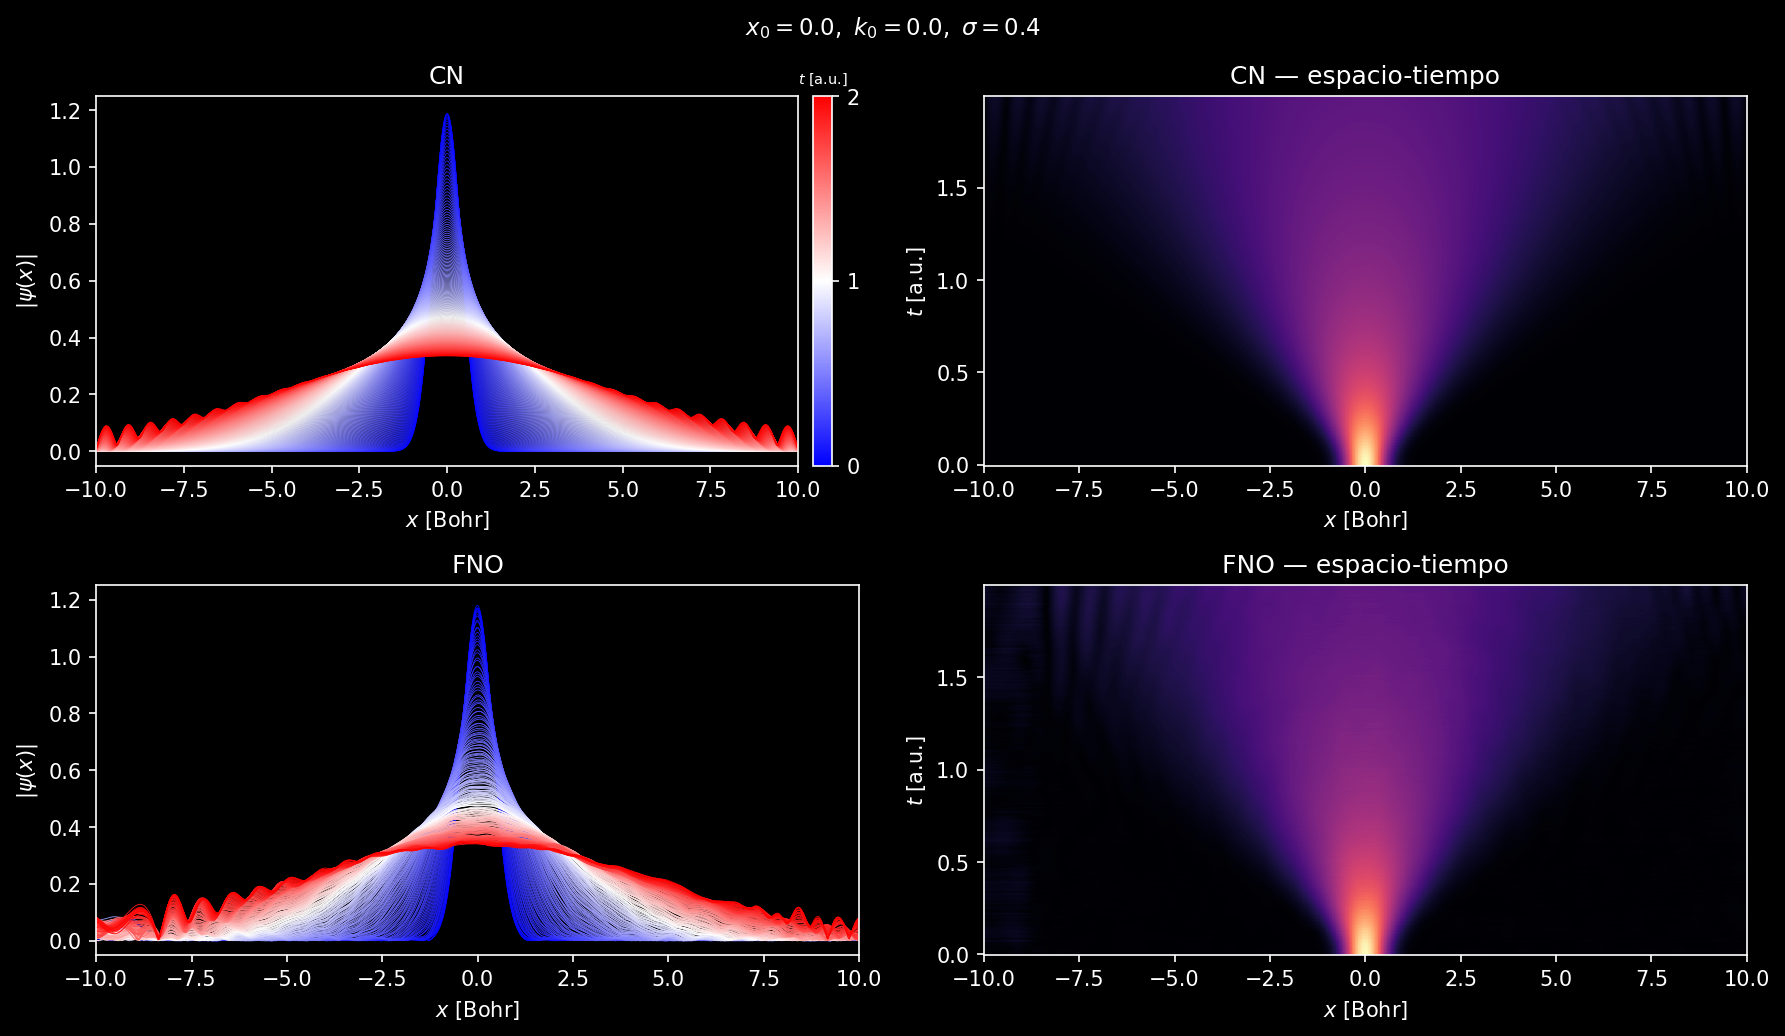

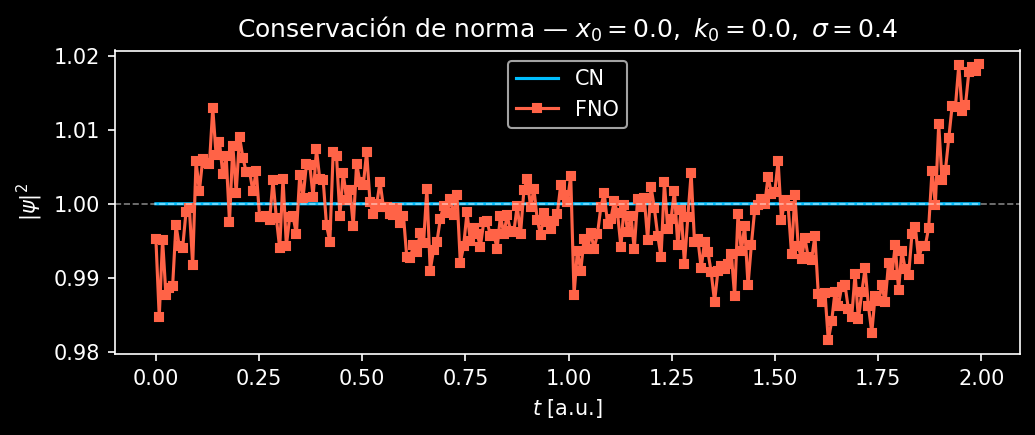

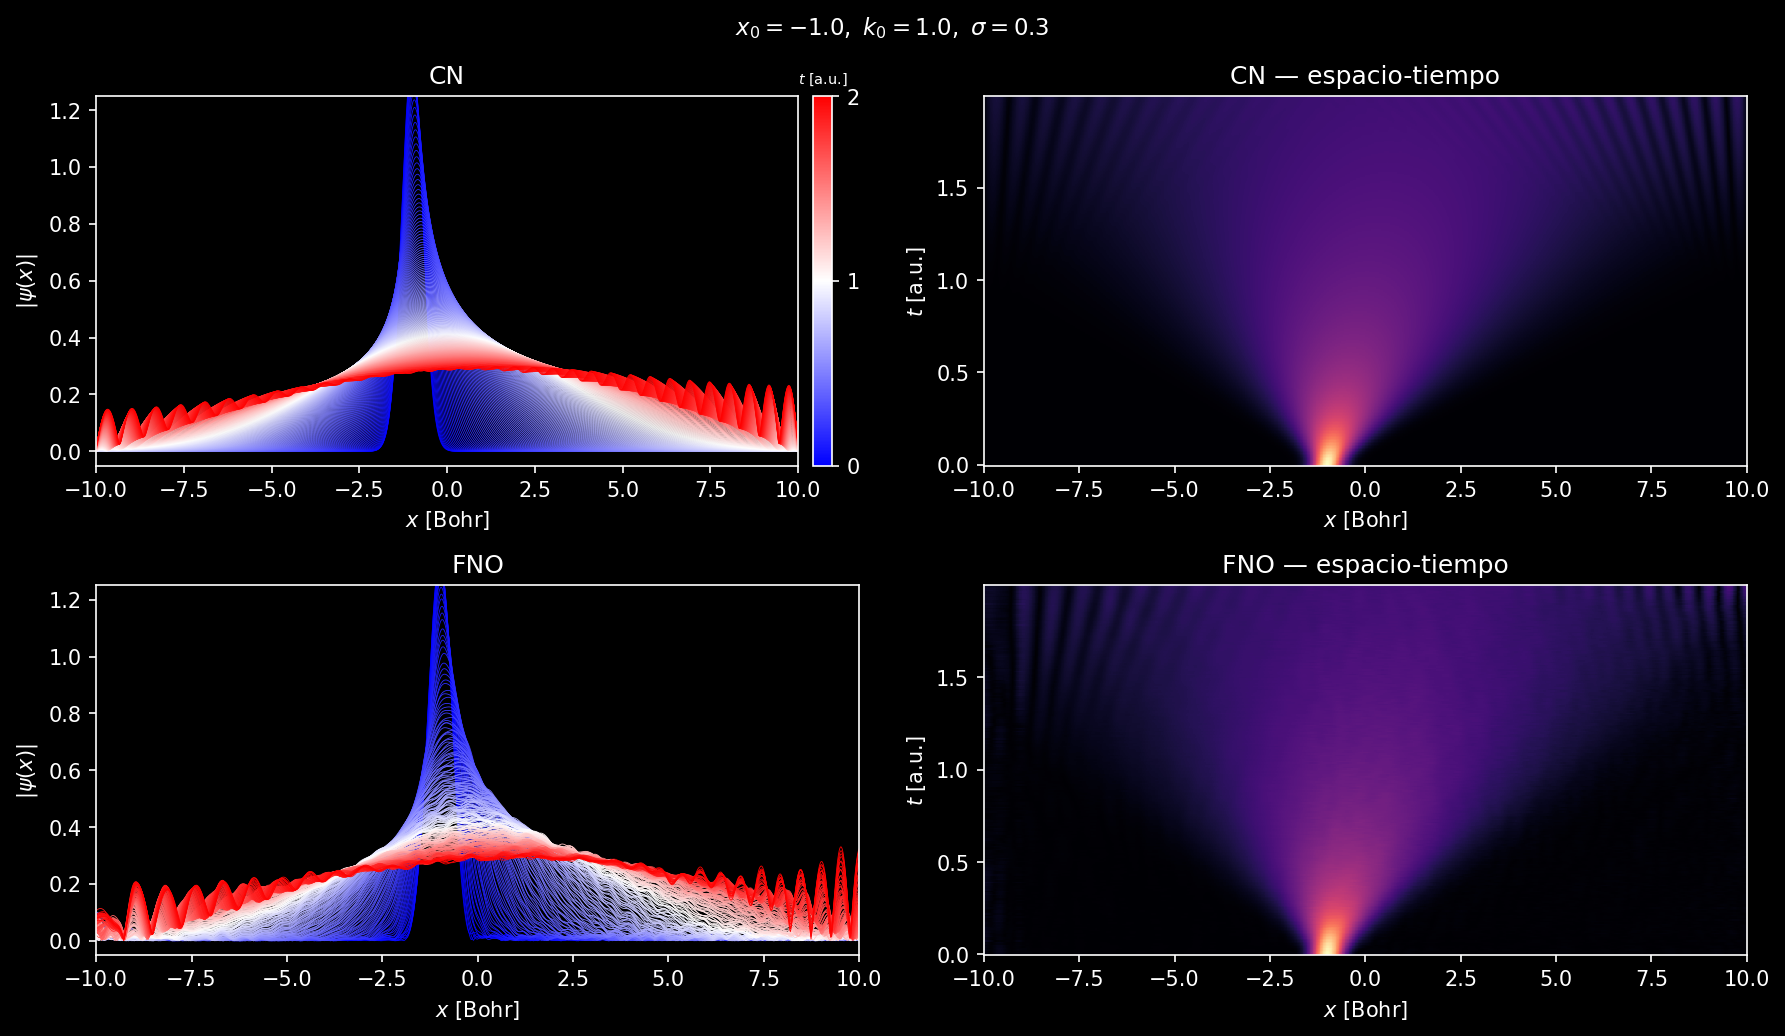

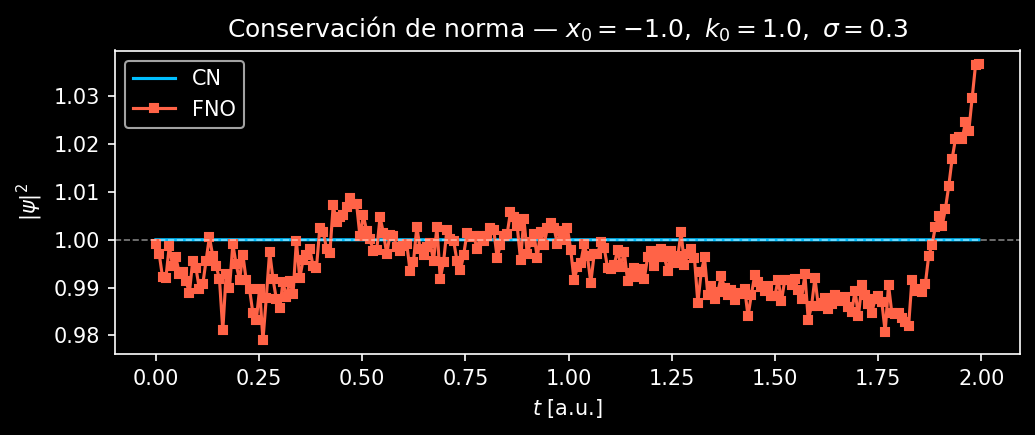

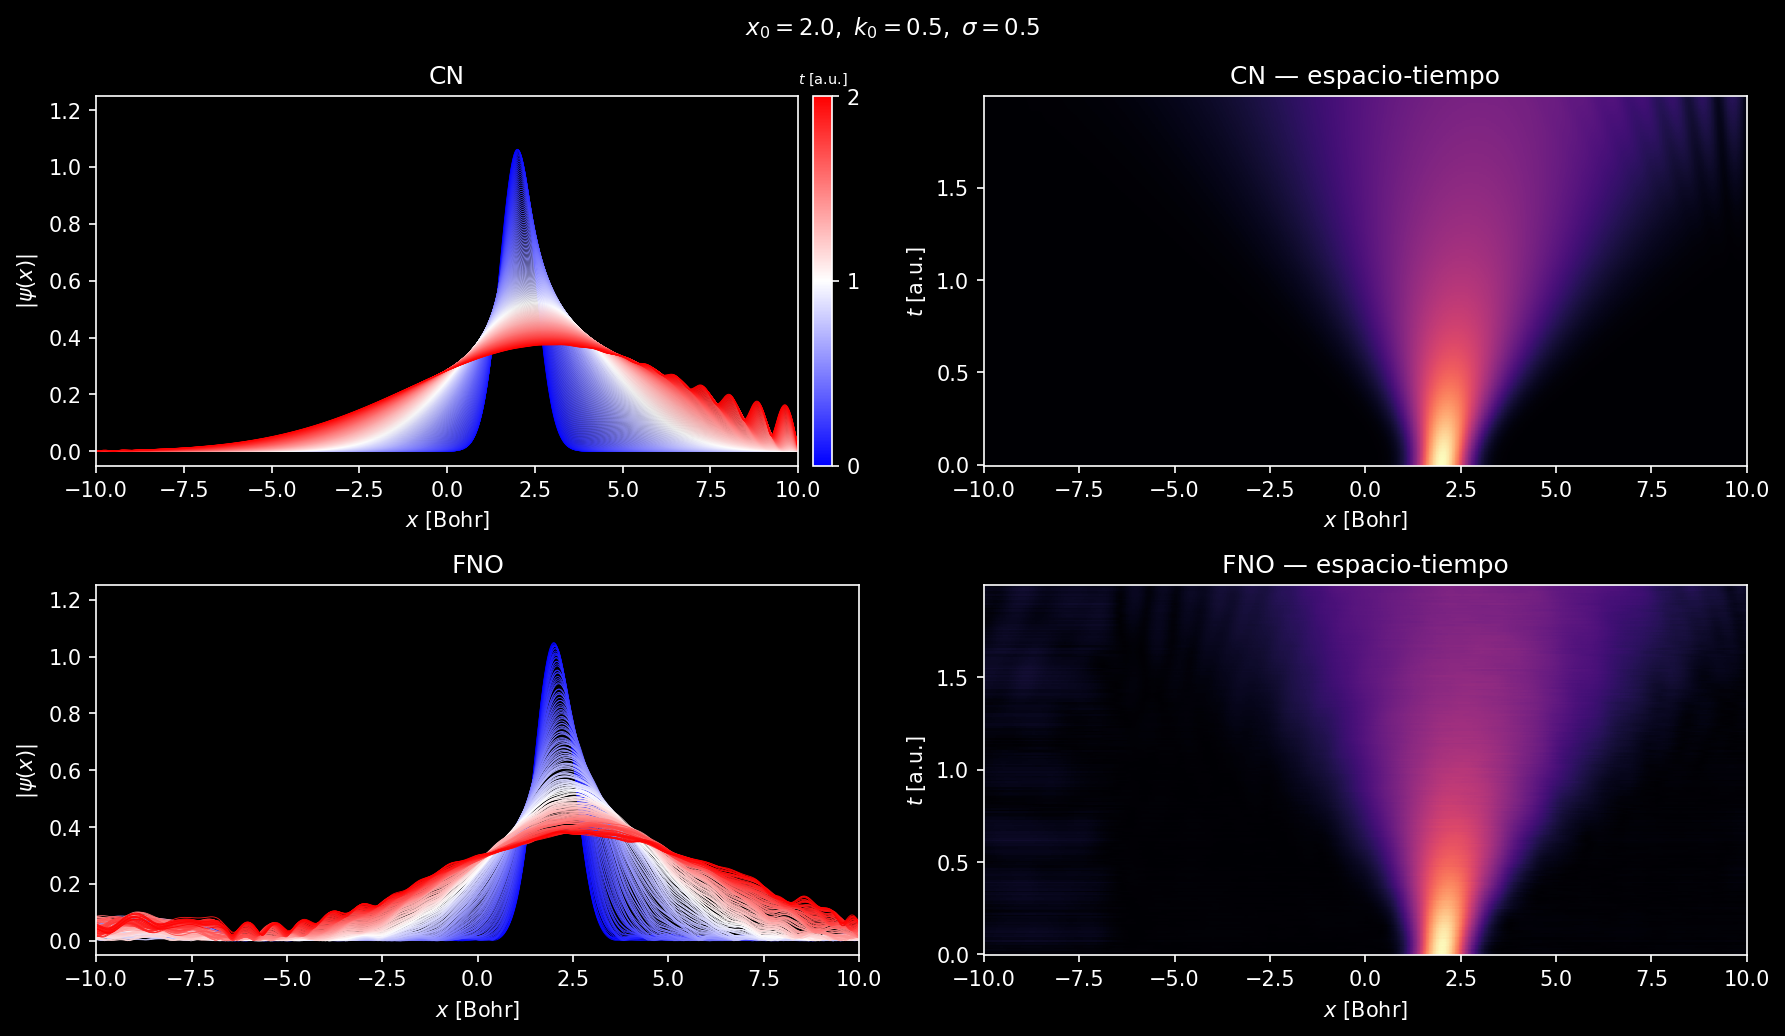

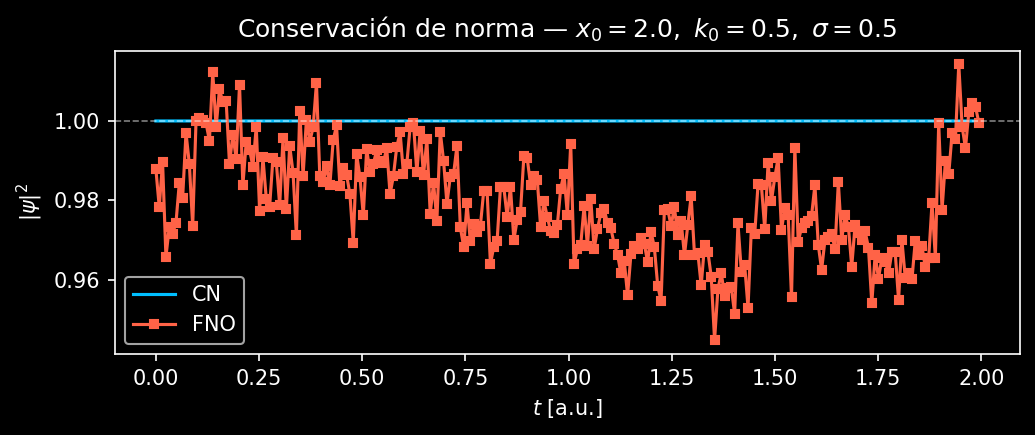

In [25]:
casos = [
    {"x0": 0.0, "k0": 0.0, "sigma": 0.4},
    {"x0": -1.0, "k0": 1.0, "sigma": 0.3},
    {"x0": 2.0, "k0": 0.5, "sigma": 0.5}
]

for caso in casos:
    psi0_c = gaussian_wavepacket(x, x0=caso["x0"], k=caso["k0"], sigma=caso["sigma"])
    psi0_c /= np.sqrt(compute_norm(psi0_c, x))

    PSI_cn_c = solve_CN_full(psi0_c, LU, U1, N_steps)

    x_in_c   = jnp.array(np.stack([psi0_c.real, psi0_c.imag], axis=-1)[None, None], dtype=jnp.float32)
    y_pred_c  = np.array(model.apply({"params": best_params}, x_in_c)[0])
    PSI_fno_c = y_pred_c[..., 0] + 1j * y_pred_c[..., 1]

    fig, axes = plt.subplots(2, 2, figsize=(12, 7), dpi=150)
    plt.style.use('dark_background')
    fig.suptitle(r"$x_0={caso['x0']},
k_0={caso['k0']},
\sigma={caso['sigma']}$", fontsize=11)

    for row, (label, PSI) in enumerate([("CN", PSI_cn_c), ("FNO", PSI_fno_c)]):
        ax = axes[row, 0]
        if label == "CN":
            for ii in range(N_steps):
                ax.plot(x, np.abs(PSI[:, ii]), color=mpl.cm.bwr(ii / N_steps), lw=0.4)
            fig.colorbar(
                mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=N_steps*dt), cmap='bwr'),
                ax=ax, fraction=0.06, pad=0.02, shrink=1.0, ticks=range(3)
            ).ax.set_title(r'$t$ [a.u.]', fontsize='x-small')
        else:
            for ii in range(PSI_fno_c.shape[0]):
                ax.plot(x, np.abs(PSI[ii, :]), color=mpl.cm.bwr(ii / PSI_fno_c.shape[0]), lw=0.4)
        ax.set_xlim(-L/2, L/2); ax.set_ylim(-0.05, 1.25)
        ax.set_xlabel(r'$x$ [Bohr]'); ax.set_ylabel(r'$|\psi(x)|$')
        ax.set_title(label)

        ax = axes[row, 1]
        if label == "CN":
            t_ax     = np.arange(N_steps) * dt
            PSI_plot = np.abs(PSI_cn_c).T
        else:
            t_ax     = t_out[:PSI_fno_c.shape[0]]
            PSI_plot = np.abs(PSI_fno_c)
        ax.pcolormesh(x, t_ax, PSI_plot, cmap='magma', shading='auto')
        ax.set_xlabel(r'$x$ [Bohr]'); ax.set_ylabel(r'$t$ [a.u.]')
        ax.set_title(f"{label} — espacio-tiempo"); ax.set_xlim(-L/2, L/2)

    plt.tight_layout()
    plt.savefig(f"comparacion_x0{caso['x0']}_k0{caso['k0']}_sigma{caso['sigma']}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    # Norma por separado
    fig_n, ax_n = plt.subplots(figsize=(7, 3), dpi=150)
    plt.style.use('dark_background')
    norms_cn_c  = [np.trapezoid(np.abs(PSI_cn_c[:, i])**2, x) for i in range(N_steps)]
    norms_fno_c = [np.trapezoid(np.abs(PSI_fno_c[i, :])**2, x) for i in range(PSI_fno_c.shape[0])]
    ax_n.plot(np.arange(N_steps)*dt,          norms_cn_c,  '-',  color='deepskyblue', lw=1.5, label='CN')
    ax_n.plot(t_out[:PSI_fno_c.shape[0]], norms_fno_c, 's-', color='tomato',      lw=1.5, ms=4,  label='FNO')
    ax_n.axhline(1.0, color='white', lw=0.8, ls='--', alpha=0.5)
    ax_n.set_xlabel(r'$t$ [a.u.]'); ax_n.set_ylabel(r'$|\psi|^2$')
    ax_n.set_title(r"Conservación de norma — $x_0={caso['x0']},
k_0={caso['k0']},
\sigma={caso['sigma']}$")
    ax_n.legend()
    plt.tight_layout()
    plt.savefig(f"norma_x0{caso['x0']}_k0{caso['k0']}_sigma{caso['sigma']}.png",
                dpi=150, bbox_inches='tight')
    plt.show()